In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

## Data Findings

In [9]:
df = pd.read_csv("bank-additional-full.csv", delimiter=";")

In [10]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [11]:
df['y'].value_counts()

no     36548
yes     4640
Name: y, dtype: int64

In [12]:
df.shape

(41188, 21)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [14]:
# all input variables
inputX = [x for x in df.columns if x != 'y']
inputX

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [17]:
# segregate categorical and numerical variables
numericalVariables = df._get_numeric_data().columns
numericalVariables = list(set(numericalVariables))
print("Numerical Variables: ")
print(numericalVariables)
print()

categoricalVariables = list(set(inputX) - set(numericalVariables))
print("Categorical Variables: ")
print(categoricalVariables)

Numerical Variables: 
['cons.conf.idx', 'emp.var.rate', 'age', 'campaign', 'previous', 'euribor3m', 'duration', 'cons.price.idx', 'nr.employed', 'pdays']

Categorical Variables: 
['loan', 'job', 'contact', 'day_of_week', 'education', 'month', 'marital', 'default', 'housing', 'poutcome']


## Percentage Distribution of Data

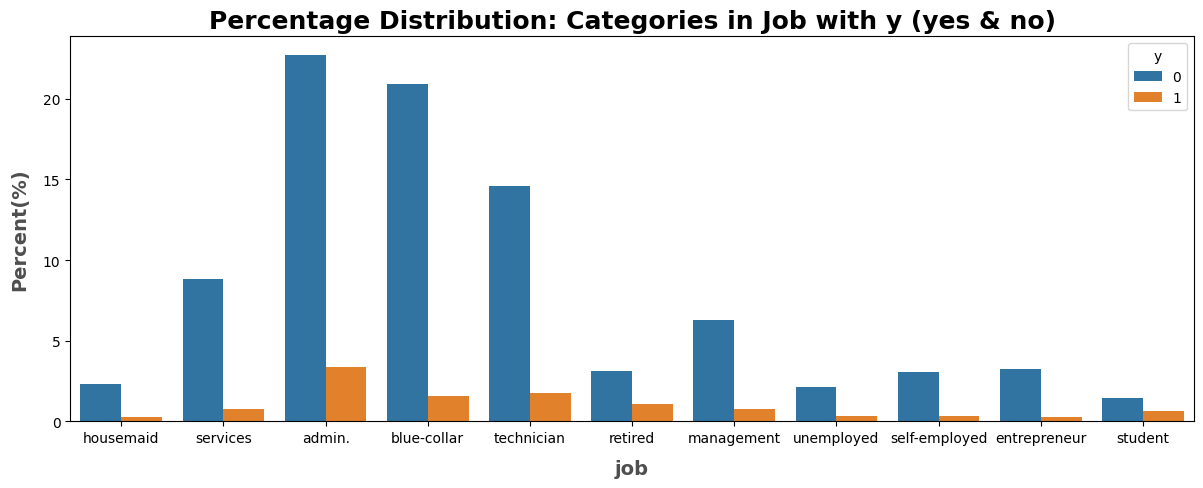

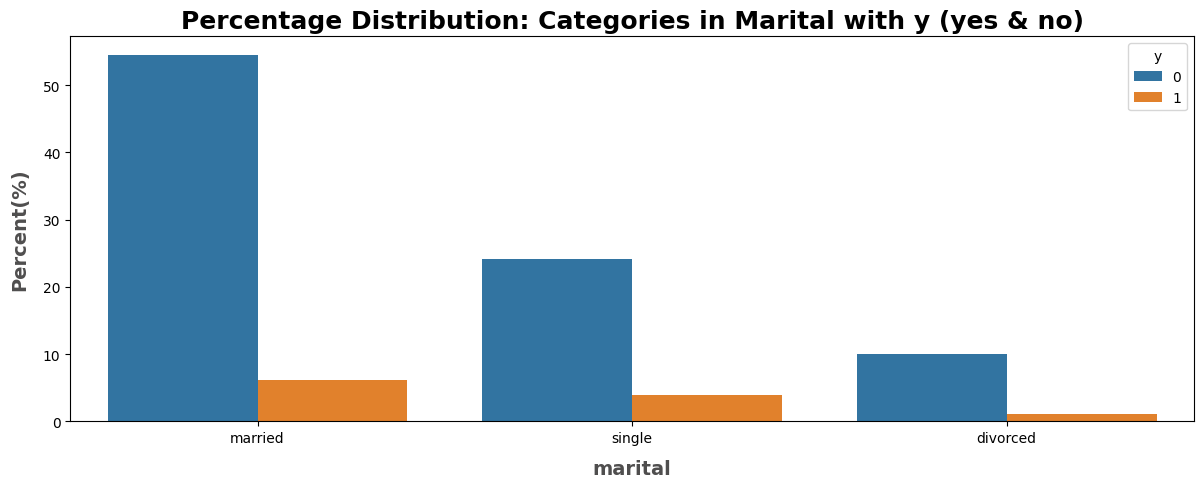

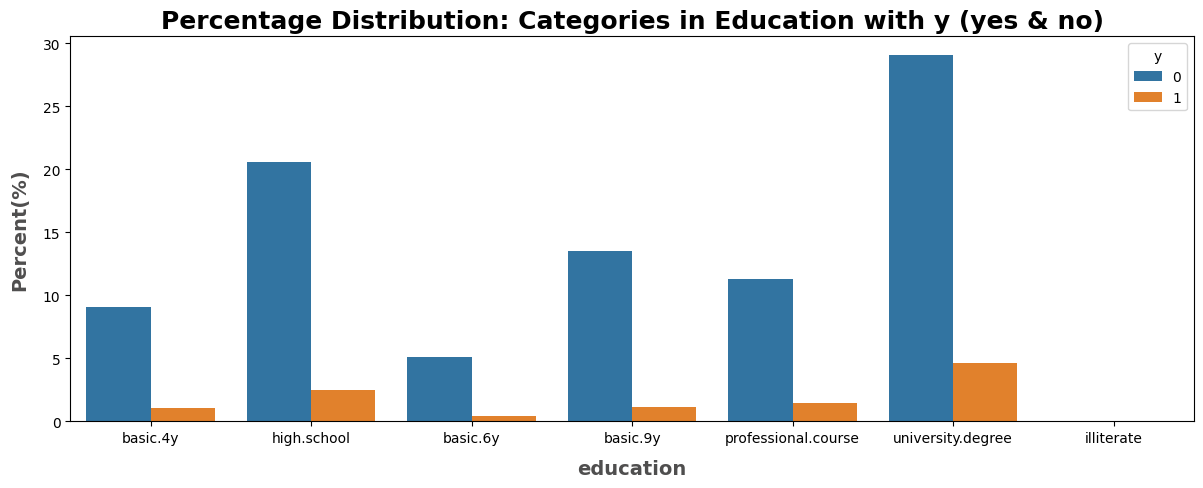

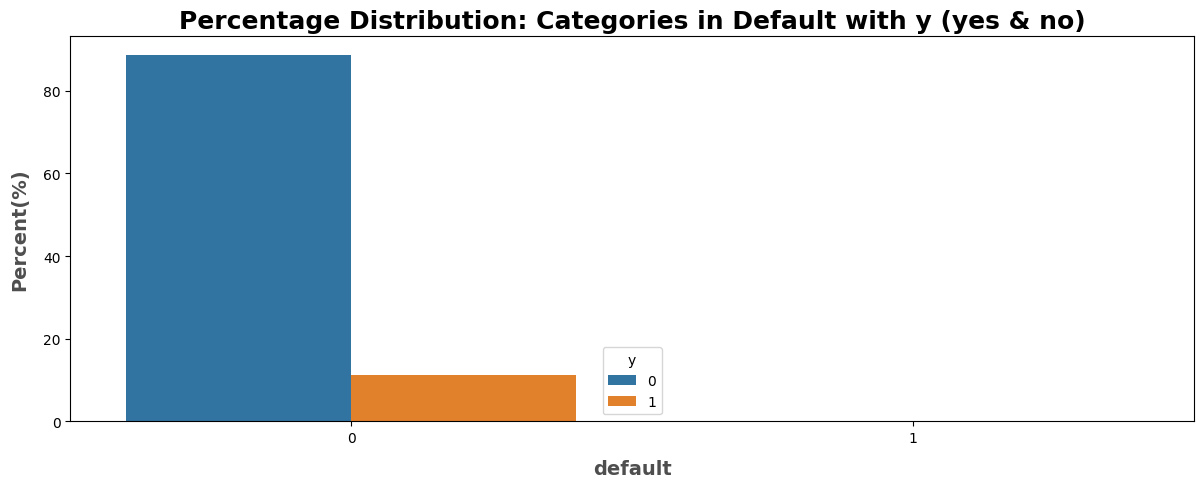

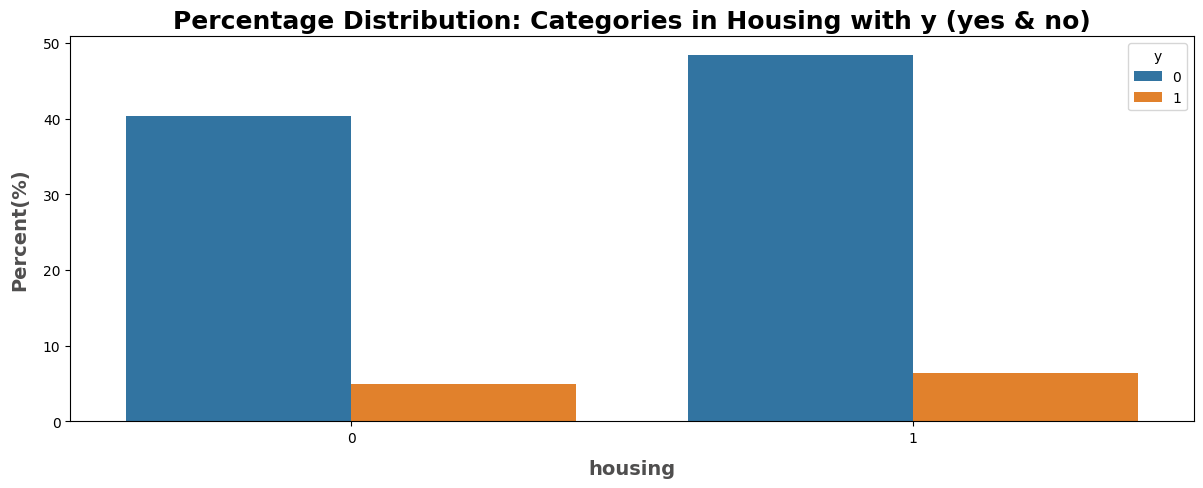

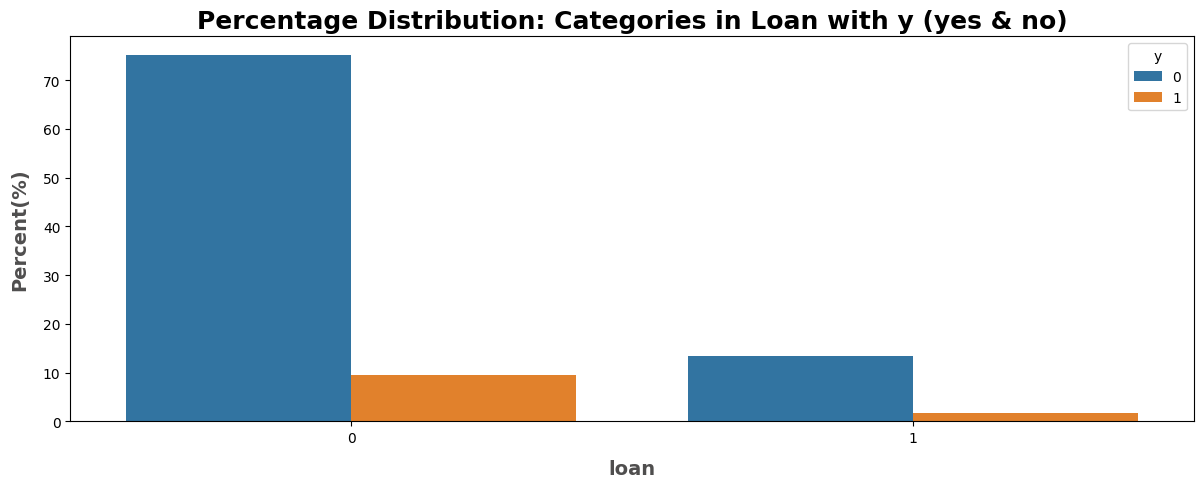

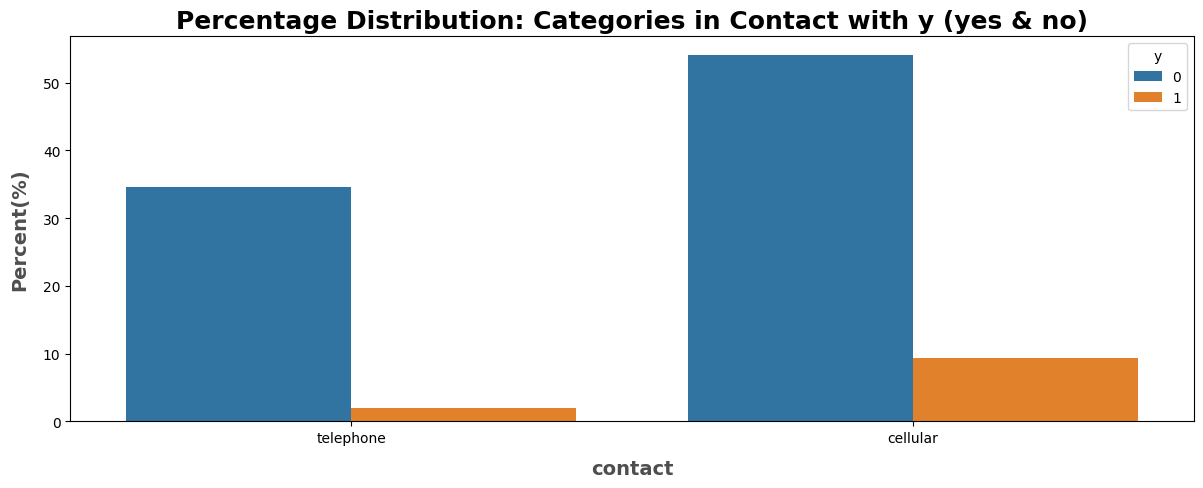

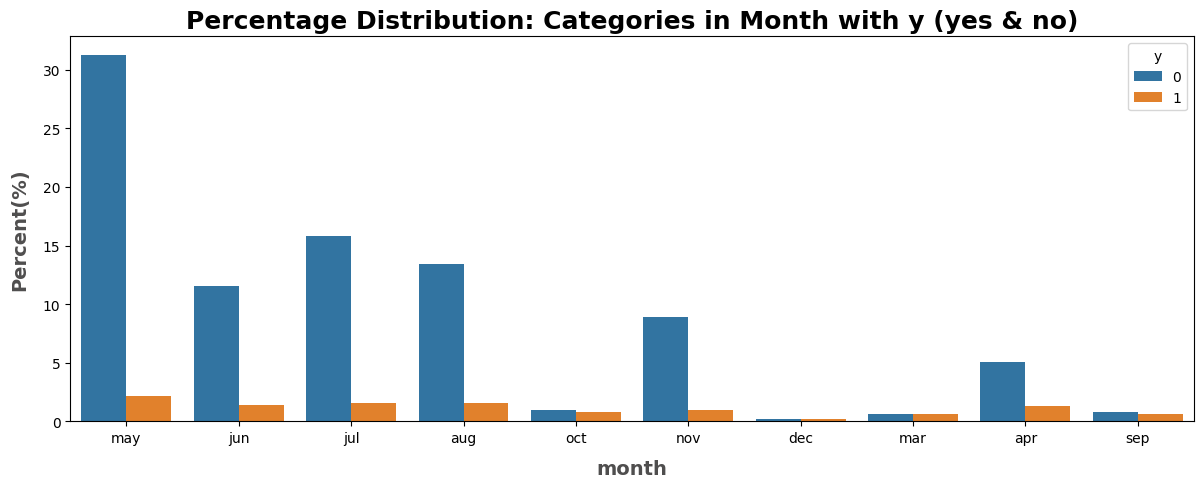

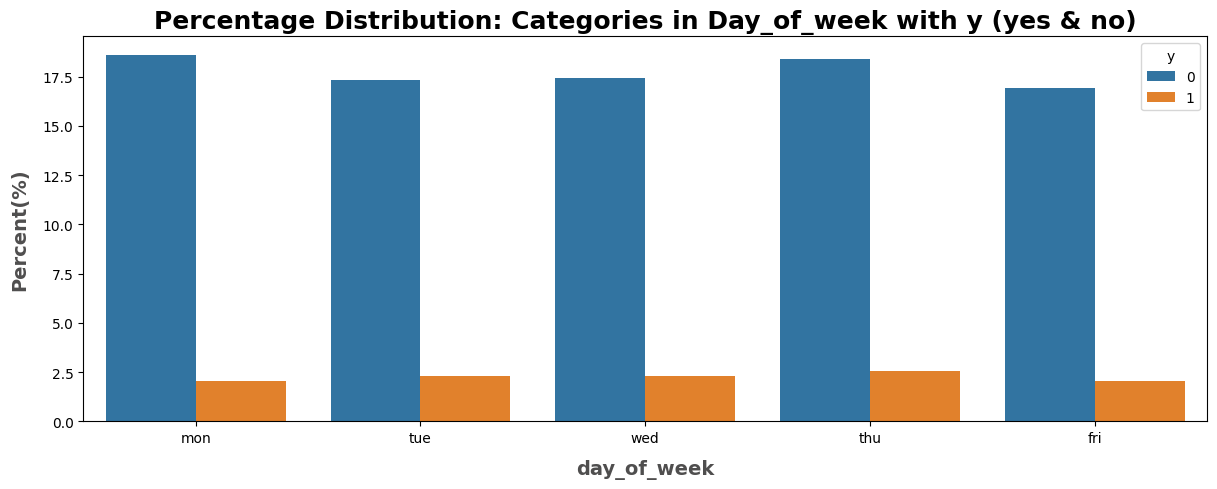

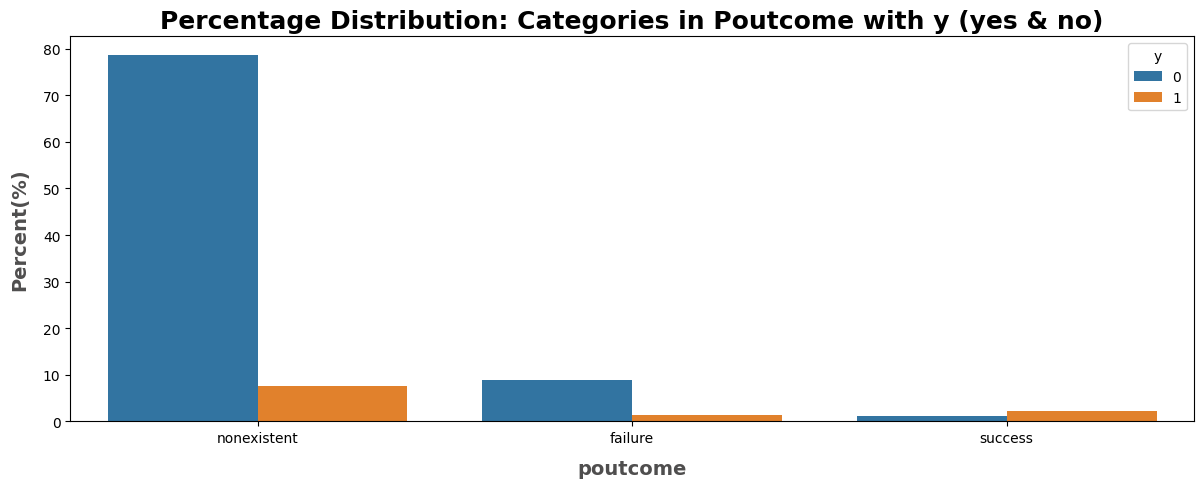

In [59]:
for i, col in enumerate(df.columns):   
    if col in categoricalVariables:
        fig = plt.figure(figsize=(14.5,5))
        df[col+'_percent'] = df.groupby(['y', col])[col].transform(lambda x: len(x)*100) / len(df)
        sns.barplot(x=col, y=col+'_percent', hue='y', data=df).set(xlabel=col, ylabel='Percent(%)') 
        plt.xlabel(xlabel=col,size=14, color='#4f4e4e',labelpad=10,fontweight='bold')
        plt.ylabel(ylabel='Percent(%)',size=14, color='#4f4e4e', labelpad=10, fontweight='bold')
        plotTitle = "Percentage Distribution: Categories in "+ col.capitalize() + " with y (yes & no)"
        plt.title(plotTitle,size=18, fontweight='bold')
        plt.show()
        df = df.drop(columns=[col+'_percent'])

## Clean Data & Replace unknowns

In [23]:
attributesWithUnknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']

for col in attributesWithUnknown:
    mostFrequent = df[col].mode()[0]
    df[col] = df[col].replace('unknown', mostFrequent)

In [24]:
# 999 means "not contacted" — replace with 0 or NaN before stats
df['pdays'] = df['pdays'].replace(999, 0)

In [25]:
# yes/no columns → 1/0
binary_cols = ['default', 'housing', 'loan', 'y']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [26]:
# Binning age
df['age_bin'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100],
                        labels=['<25','25-35','35-45','45-55','55-65','65+'])

# Binning pdays
df['pdays_bin'] = pd.cut(df['pdays'], bins=[-1,0,7,14,30,100],
                          labels=['not_contacted','1w','2w','1m','1m+'])

In [27]:
categorical_cols = ['contact', 'default', 'day_of_week', 'job', 'housing',
                    'education', 'loan', 'poutcome', 'month', 'marital']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [28]:
df_encoded

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,marital_married,marital_single
0,56,261,1,0,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,0,1,0,0,0,1,0
1,57,149,1,0,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,0,1,0,0,0,1,0
2,37,226,1,0,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,0,1,0,0,0,1,0
3,40,151,1,0,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,0,1,0,0,0,1,0
4,56,307,1,0,0,1.1,93.994,-36.4,4.857,5191.0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,0,0,-1.1,94.767,-50.8,1.028,4963.6,...,0,0,0,0,0,1,0,0,1,0
41184,46,383,1,0,0,-1.1,94.767,-50.8,1.028,4963.6,...,0,0,0,0,0,1,0,0,1,0
41185,56,189,2,0,0,-1.1,94.767,-50.8,1.028,4963.6,...,0,0,0,0,0,1,0,0,1,0
41186,44,442,1,0,0,-1.1,94.767,-50.8,1.028,4963.6,...,0,0,0,0,0,1,0,0,1,0


##  Mean, Median, Standard Deviation & Correlation

In [29]:
df_encoded.select_dtypes(include='number').agg(['mean', 'median', 'std'])

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,marital_married,marital_single
mean,40.02406,258.285010,2.567593,0.221229,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,...,0.004419,0.174177,0.129115,0.013256,0.334296,0.099568,0.017432,0.013839,0.607167,0.280859
median,38.00000,180.000000,2.000000,0.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
std,10.42125,259.279249,2.770014,1.348874,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,...,0.066328,0.379266,0.335332,0.114372,0.471750,0.299427,0.130877,0.116824,0.488386,0.449424


In [30]:
df_encoded.select_dtypes(include='number').corr()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,marital_married,marital_single
age,1.000000,-0.000866,4.593580e-03,0.018132,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725,...,0.046563,-0.043563,-0.009532,0.008390,-0.067523,0.030045,0.053008,0.040889,0.271596,-0.411703
duration,-0.000866,1.000000,-7.169923e-02,0.047853,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703,...,0.022438,0.026819,-0.023351,-0.005516,0.008054,-0.015941,0.015454,0.018011,-0.003210,0.007808
campaign,0.004594,-0.071699,1.000000e+00,-0.041984,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095,...,-0.009819,0.098385,0.070144,-0.015244,-0.032704,-0.079028,-0.049126,-0.033953,0.003224,-0.007624
pdays,0.018132,0.047853,-4.198361e-02,1.000000,0.485182,-0.218942,-0.041787,0.064192,-0.251822,-0.323122,...,0.065873,-0.030189,-0.020102,0.077621,-0.056398,0.003170,0.111835,0.127714,-0.029798,0.039683
previous,0.024365,0.020640,-7.914147e-02,0.485182,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333,...,0.059557,-0.116785,-0.069905,0.072733,-0.012534,0.081050,0.127754,0.157651,-0.042638,0.048485
emp.var.rate,-0.000371,-0.027968,1.507538e-01,-0.218942,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970,...,-0.124174,0.314863,0.148653,-0.138849,-0.111356,-0.105917,-0.213706,-0.170366,0.079490,-0.099403
cons.price.idx,0.000857,0.005312,1.278359e-01,-0.041787,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034,...,-0.099017,0.253303,0.445513,-0.095783,-0.057274,-0.215273,-0.092174,-0.046905,0.045747,-0.063013
cons.conf.idx,0.129372,-0.008173,-1.373310e-02,0.064192,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513,...,0.097795,-0.185320,-0.089588,-0.053793,-0.011740,-0.052892,0.170425,0.169175,0.061833,-0.056186
euribor3m,0.010767,-0.032897,1.351325e-01,-0.251822,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154,...,-0.105860,0.281835,0.141107,-0.164298,-0.133859,0.019524,-0.185937,-0.190321,0.088278,-0.109479
nr.employed,-0.017725,-0.044703,1.440949e-01,-0.323122,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000,...,-0.124611,0.299021,0.162315,-0.179106,-0.171782,0.027593,-0.273236,-0.292156,0.082020,-0.102382


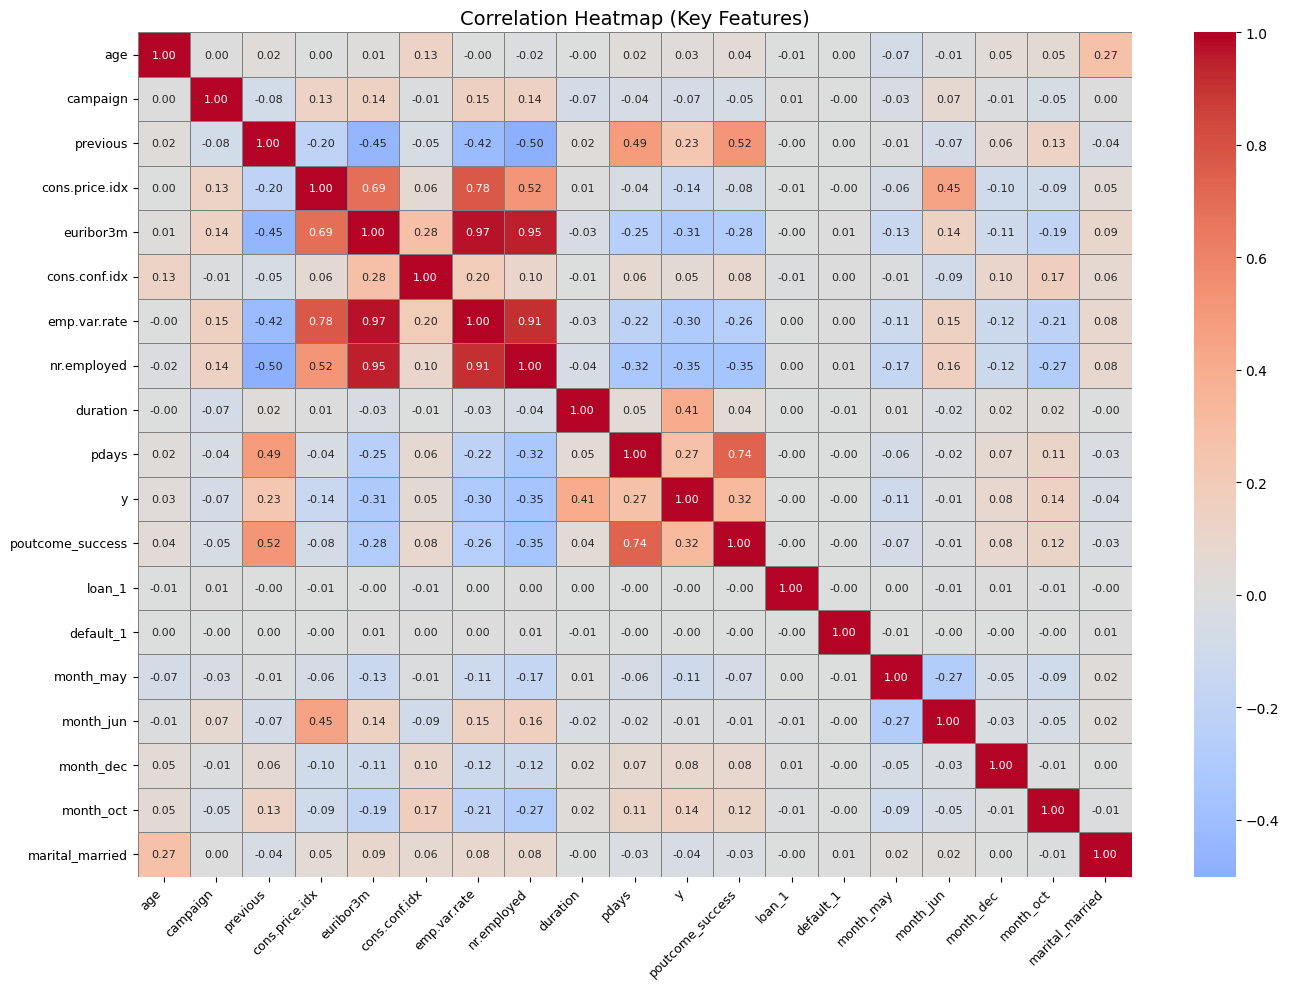

In [32]:
# Keep only original numerical columns + target + key encoded features
cols_to_keep = [
    # Core numerical
    'age', 'campaign', 'previous', 'cons.price.idx', 'euribor3m',
    'cons.conf.idx', 'emp.var.rate', 'nr.employed', 'duration', 'pdays',
    # Target
    'y',
    # Key encoded (only the most meaningful ones)
    'poutcome_success', 'loan_1', 'default_1',
    'month_may', 'month_jun', 'month_dec', 'month_oct',
    'marital_married'
]

# Filter only columns that exist in your df
cols_to_keep = [c for c in cols_to_keep if c in df_encoded.columns]
df_corr = df_encoded[cols_to_keep].corr()

# Plot
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_corr,
    annot=True,
    fmt='.2f',          # 2 decimal places
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap (Key Features)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

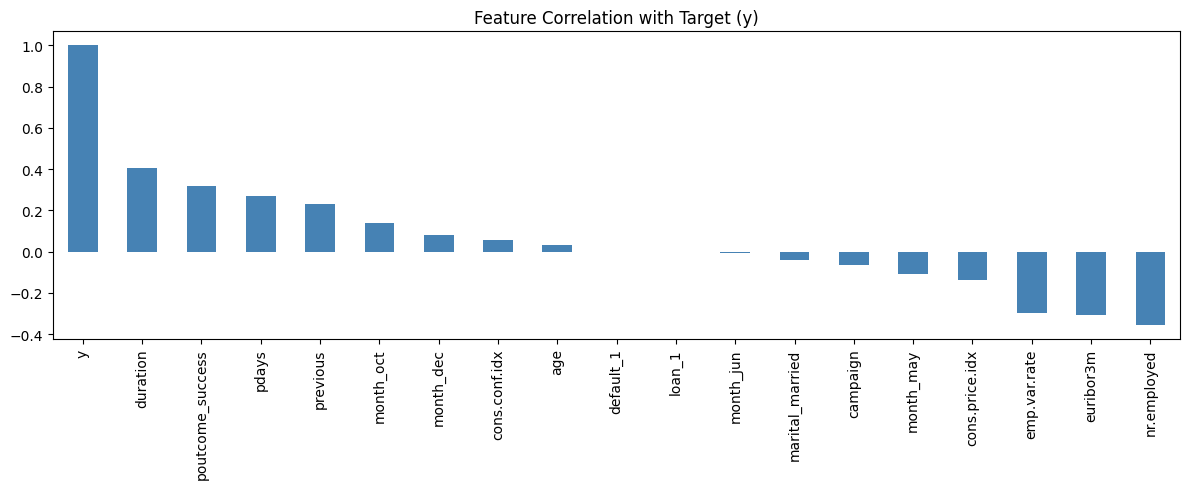

In [33]:
## For simpler view
df_encoded[cols_to_keep].corr()['y'].sort_values(ascending=False).plot(
    kind='bar', figsize=(12, 5), title='Feature Correlation with Target (y)', color='steelblue'
)
plt.tight_layout()
plt.show()

## Data Visualization

### Class Distribution

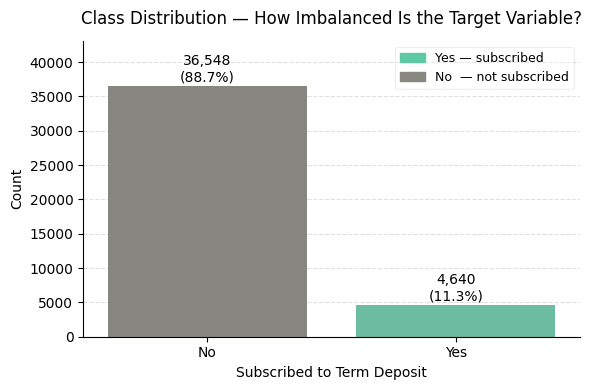

In [40]:
df_encoded['y_label'] = df_encoded['y'].map({0: 'No', 1: 'Yes'})

counts = df_encoded['y_label'].value_counts()
total = len(df_encoded)

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    x='y_label',
    data=df_encoded,
    order=['No', 'Yes'],
    palette={'No': '#888780', 'Yes': '#5DCAA5'},
    ax=ax
)

# Add count + percentage labels on bars
for bar, label in zip(ax.patches, ['No', 'Yes']):
    count = counts.get(label, 0)
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )

# Styling
ax.set_title('Class Distribution — How Imbalanced Is the Target Variable?', fontsize=12, pad=12)
ax.set_xlabel('Subscribed to Term Deposit')
ax.set_ylabel('Count')
ax.set_xticklabels(['No', 'Yes'])
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylim(0, counts.max() * 1.18)

legend = [
    mpatches.Patch(color='#5DCAA5', label=f"Yes — subscribed"),
    mpatches.Patch(color='#888780', label=f"No  — not subscribed")
]
ax.legend(handles=legend, fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.show()

### Subscription rate by job type — which professions say yes most?

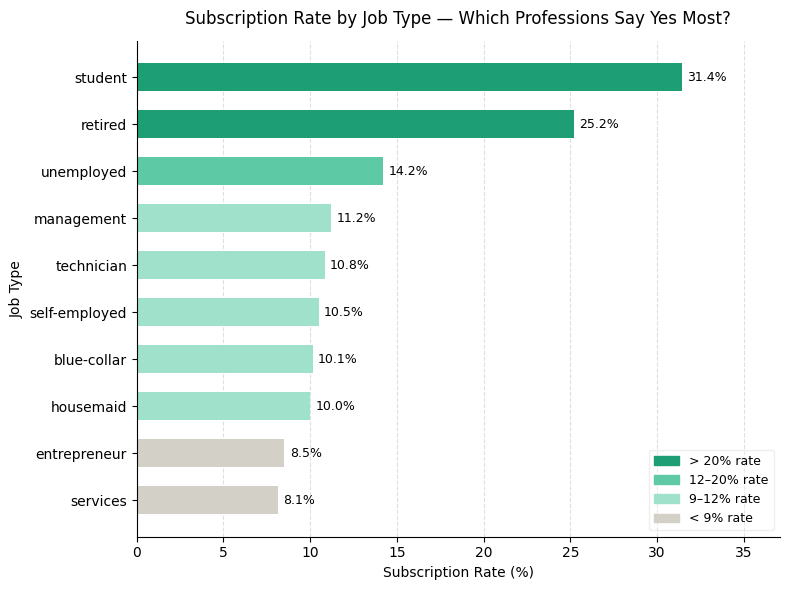

In [43]:
# Calculate subscription rate by job
job_cols = [c for c in df_encoded.columns if c.startswith('job_')]
df_encoded['job'] = df_encoded[job_cols].idxmax(axis=1).str.replace('job_', '')
job_sub = df_encoded.groupby('job')['y'].mean() * 100
job_sub_rate = job_sub.sort_values(ascending=True)

# Colors based on rate
colors = ['#1D9E75' if r > 20 else '#5DCAA5' if r > 12 else '#9FE1CB' if r > 9 else '#D3D1C7' 
          for r in job_sub_rate]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(
    job_sub_rate.index,
    job_sub_rate.values,
    color=colors,
    edgecolor='none',
    height=0.6
)

# Add percentage labels on bars
for bar, val in zip(bars, job_sub_rate.values):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', fontsize=9
    )

# Styling
ax.set_title('Subscription Rate by Job Type — Which Professions Say Yes Most?',
             fontsize=12, pad=12)
ax.set_xlabel('Subscription Rate (%)')
ax.set_ylabel('Job Type')
ax.set_xlim(0, job_sub_rate.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Legend
import matplotlib.patches as mpatches
legend = [
    mpatches.Patch(color='#1D9E75', label='> 20% rate'),
    mpatches.Patch(color='#5DCAA5', label='12–20% rate'),
    mpatches.Patch(color='#9FE1CB', label='9–12% rate'),
    mpatches.Patch(color='#D3D1C7', label='< 9% rate'),
]
ax.legend(handles=legend, fontsize=9, framealpha=0.3, loc='lower right')

plt.tight_layout()
plt.show()

### Subscription rate by month — when is the best time to call?

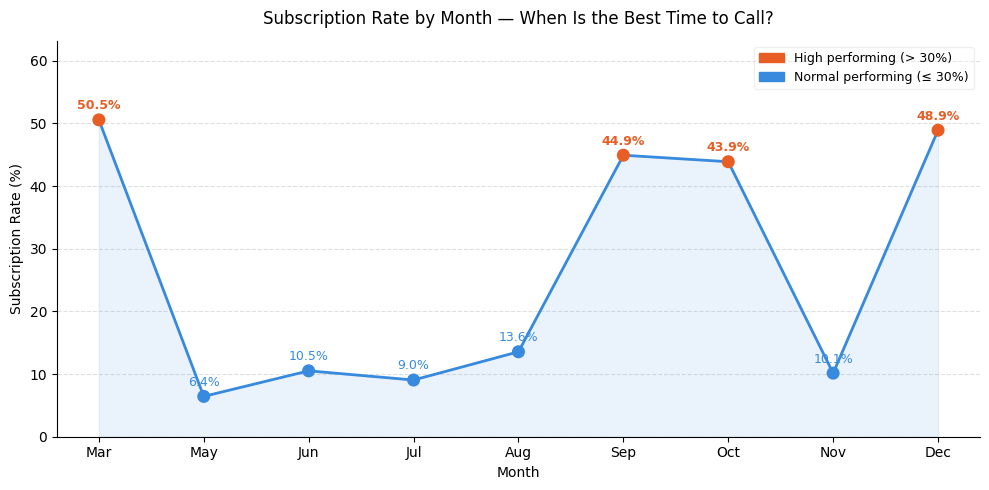

In [45]:
# Recover month column from one-hot encoded columns
month_cols = [c for c in df_encoded.columns if c.startswith('month_')]
df_encoded['month'] = df_encoded[month_cols].idxmax(axis=1).str.replace('month_', '')

# Month order
month_order = ['jan','feb','mar','apr','may','jun',
                'jul','aug','sep','oct','nov','dec']

# Subscription rate by month
month_sub = df_encoded.groupby('month')['y'].mean() * 100
month_sub_rate = month_sub.reindex(month_order).dropna()

# Color: highlight high-performing months
colors = ['#E85D24' if r > 30 else '#378ADD' for r in month_sub_rate.values]

fig, ax = plt.subplots(figsize=(10, 5))

# Line plot
ax.plot(
    month_sub_rate.index,
    month_sub_rate.values,
    color='#378ADD',
    linewidth=2,
    zorder=1
)

# Shaded area under line
ax.fill_between(
    month_sub_rate.index,
    month_sub_rate.values,
    alpha=0.1,
    color='#378ADD'
)

# Scatter points (colored by performance)
ax.scatter(
    month_sub_rate.index,
    month_sub_rate.values,
    color=colors,
    s=70,
    zorder=2
)

# Add percentage labels above each point
for month, val, color in zip(month_sub_rate.index, month_sub_rate.values, colors):
    ax.text(
        month, val + 1.2,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=9,
        color=color,
        fontweight='bold' if color == '#E85D24' else 'normal'
    )

# Styling
ax.set_title('Subscription Rate by Month — When Is the Best Time to Call?',
             fontsize=12, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Subscription Rate (%)')
ax.set_xticks(range(len(month_sub_rate.index)))
ax.set_xticklabels([m.capitalize() for m in month_sub_rate.index])
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylim(0, month_sub_rate.max() * 1.25)

# Legend
legend = [
    mpatches.Patch(color='#E85D24', label='High performing (> 30%)'),
    mpatches.Patch(color='#378ADD', label='Normal performing (≤ 30%)'),
]
ax.legend(handles=legend, fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.show()

# Drop temp column to keep df_encoded clean
df_encoded.drop(columns='month', inplace=True)

### Call duration vs subscription — does longer always mean better?

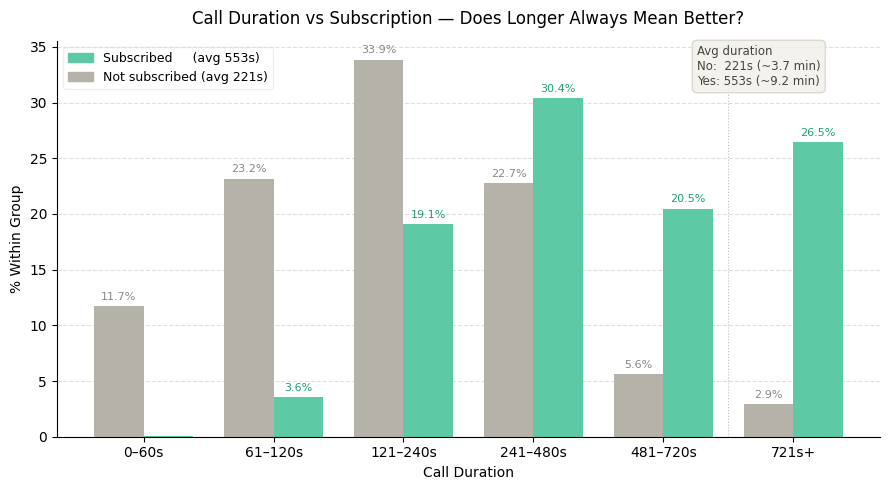

In [46]:
# Define duration bins
bins   = [0, 60, 120, 240, 480, 720, float('inf')]
labels = ['0–60s', '61–120s', '121–240s', '241–480s', '481–720s', '721s+']

# Bin the duration column
df_encoded['duration_bin'] = pd.cut(
    df_encoded['duration'],
    bins=bins,
    labels=labels,
    right=True
)

# Calculate % distribution within each class
no_dist  = (df_encoded[df_encoded['y'] == 0]['duration_bin']
            .value_counts(normalize=True)
            .reindex(labels) * 100)

yes_dist = (df_encoded[df_encoded['y'] == 1]['duration_bin']
            .value_counts(normalize=True)
            .reindex(labels) * 100)

# Average duration per class
avg_no  = df_encoded[df_encoded['y'] == 0]['duration'].mean()
avg_yes = df_encoded[df_encoded['y'] == 1]['duration'].mean()

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(len(labels))
width = 0.38

bars_no  = ax.bar(x - width/2, no_dist.values,  width, color='#B4B2A9',
                  label='Not subscribed', edgecolor='none', zorder=2)
bars_yes = ax.bar(x + width/2, yes_dist.values, width, color='#5DCAA5',
                  label='Subscribed',     edgecolor='none', zorder=2)

# Value labels on bars
for bar in bars_no:
    h = bar.get_height()
    if h > 1:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='#888780')

for bar in bars_yes:
    h = bar.get_height()
    if h > 1:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='#1D9E75')

# Styling
ax.set_title('Call Duration vs Subscription — Does Longer Always Mean Better?',
             fontsize=12, pad=12)
ax.set_xlabel('Call Duration')
ax.set_ylabel('% Within Group')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Avg duration annotations
ax.axvline(x=4.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
fig.text(0.78, 0.82, f'Avg duration\nNo:  {avg_no:.0f}s (~{avg_no/60:.1f} min)\nYes: {avg_yes:.0f}s (~{avg_yes/60:.1f} min)',
         fontsize=8.5, color='#444441',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F1EFE8', edgecolor='#D3D1C7', alpha=0.8))

# Legend
legend = [
    mpatches.Patch(color='#5DCAA5', label=f'Subscribed     (avg {avg_yes:.0f}s)'),
    mpatches.Patch(color='#B4B2A9', label=f'Not subscribed (avg {avg_no:.0f}s)'),
]
ax.legend(handles=legend, fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.show()

# Drop temp column
df_encoded.drop(columns='duration_bin', inplace=True)

### Correlation heatmap — key features vs target

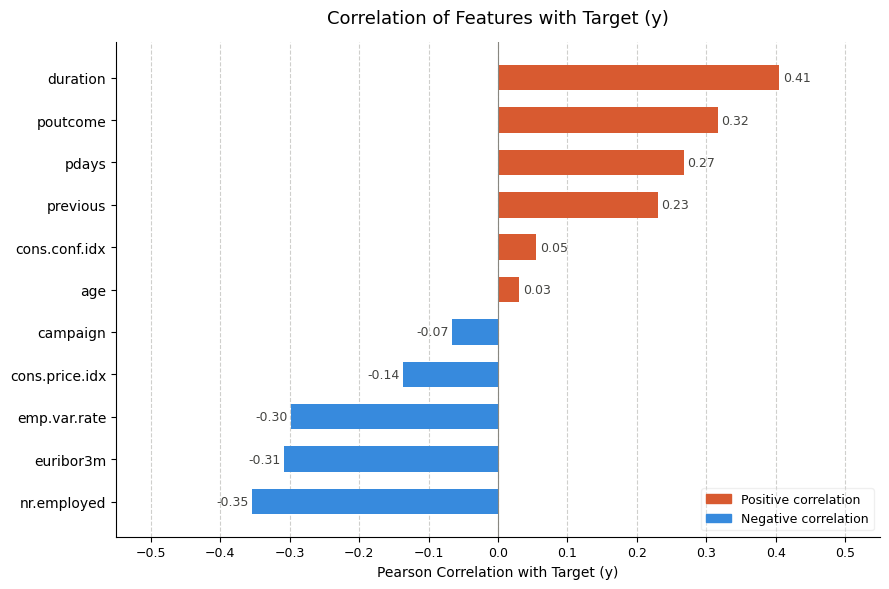

In [48]:
# Select only core numerical features
cols_numerical = [
    'duration', 'previous', 'cons.conf.idx', 'age',
    'campaign', 'cons.price.idx', 'nr.employed',
    'euribor3m', 'emp.var.rate', 'pdays'
]

# Add poutcome_success if exists
extra_cols = ['poutcome_success']
cols_numerical += [c for c in extra_cols if c in df_encoded.columns]

# Compute correlation with target y
corr_with_y = (df_encoded[cols_numerical + ['y']]
               .corr()['y']
               .drop('y')
               .sort_values(ascending=True))

# Colors: positive = coral/brown, negative = blue
colors = ['#D85A30' if v >= 0 else '#378ADD' for v in corr_with_y.values]

# Rename poutcome_success to poutcome for clean label
corr_with_y.index = [i.replace('poutcome_success', 'poutcome') for i in corr_with_y.index]

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    corr_with_y.index,
    corr_with_y.values,
    color=colors,
    edgecolor='none',
    height=0.6
)

# Add value labels on bars
for bar, val in zip(bars, corr_with_y.values):
    x_pos = bar.get_width() + 0.005 if val >= 0 else bar.get_width() - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}',
            va='center', ha=ha, fontsize=9,
            color='#444441')

# Reference line at 0
ax.axvline(0, color='#888780', linewidth=0.8, linestyle='-')

# Styling
ax.set_title('Correlation of Features with Target (y)',
             fontsize=13, pad=14)
ax.set_xlabel('Pearson Correlation with Target (y)', fontsize=10)
ax.set_xlim(-0.55, 0.55)
ax.set_xticks([-0.5, -0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#888780')
ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9)

# Legend
import matplotlib.patches as mpatches
legend = [
    mpatches.Patch(color='#D85A30', label='Positive correlation'),
    mpatches.Patch(color='#378ADD', label='Negative correlation'),
]
ax.legend(handles=legend, fontsize=9, framealpha=0.3, loc='lower right')

plt.tight_layout()
plt.show()

### Previous outcome vs subscription — does past behavior predict future?

Poutcome columns found: ['poutcome_nonexistent', 'poutcome_success']

Subscription rate by previous outcome:
             total  subscribed  not_subscribed  sub_rate
poutcome                                                
nonexistent  39815        3746           36069       9.4
success       1373         894             479      65.1


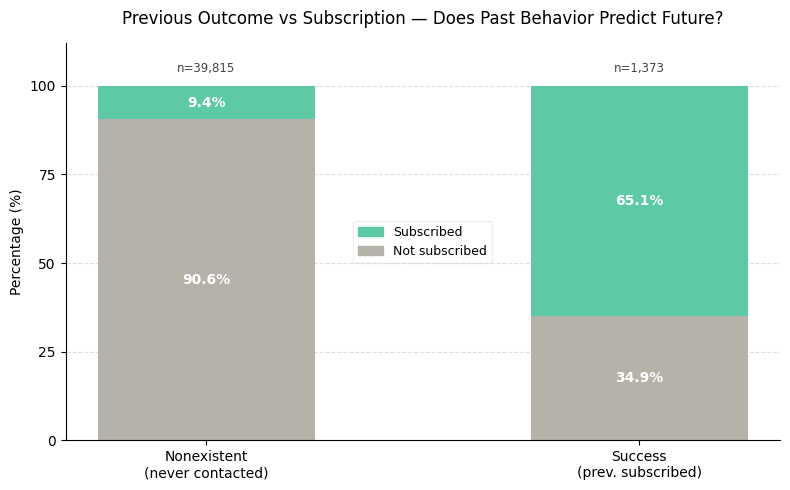

In [51]:
# Recover poutcome from one-hot encoded columns
poutcome_cols = [c for c in df_encoded.columns if c.startswith('poutcome_')]
print("Poutcome columns found:", poutcome_cols)

df_encoded['poutcome'] = df_encoded[poutcome_cols].idxmax(axis=1).str.replace('poutcome_', '')

# Calculate subscription rate per poutcome group
poutcome_group = df_encoded.groupby('poutcome')['y'].agg(
    total='count',
    subscribed='sum'
)
poutcome_group['not_subscribed'] = poutcome_group['total'] - poutcome_group['subscribed']
poutcome_group['sub_rate']       = (poutcome_group['subscribed'] / poutcome_group['total'] * 100).round(1)
poutcome_group['no_rate']        = (poutcome_group['not_subscribed'] / poutcome_group['total'] * 100).round(1)

print("\nSubscription rate by previous outcome:")
print(poutcome_group[['total', 'subscribed', 'not_subscribed', 'sub_rate']])

# Define display order and clean labels
order       = ['nonexistent', 'failure', 'success']
order       = [o for o in order if o in poutcome_group.index]
clean_labels = {
    'nonexistent': 'Nonexistent\n(never contacted)',
    'failure'    : 'Failure\n(prev. declined)',
    'success'    : 'Success\n(prev. subscribed)'
}

sub_rates = [poutcome_group.loc[o, 'sub_rate'] for o in order]
no_rates  = [poutcome_group.loc[o, 'no_rate']  for o in order]
x_labels  = [clean_labels.get(o, o) for o in order]

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

x     = np.arange(len(order))
width = 0.5

bars_no  = ax.bar(x, no_rates,  width, label='Not subscribed',
                  color='#B4B2A9', edgecolor='none', zorder=2)
bars_yes = ax.bar(x, sub_rates, width, label='Subscribed',
                  bottom=no_rates, color='#5DCAA5',
                  edgecolor='none', zorder=2)

# Labels inside bars — Not subscribed
for bar, val in zip(bars_no, no_rates):
    if val > 5:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val / 2,
            f'{val:.1f}%',
            ha='center', va='center',
            fontsize=10, color='white', fontweight='bold'
        )

# Labels inside bars — Subscribed
for bar, bottom, val in zip(bars_yes, no_rates, sub_rates):
    if val > 5:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bottom + val / 2,
            f'{val:.1f}%',
            ha='center', va='center',
            fontsize=10, color='white', fontweight='bold'
        )

# Annotate total count above each bar
for i, o in enumerate(order):
    total = poutcome_group.loc[o, 'total']
    ax.text(
        i, 103,
        f'n={total:,}',
        ha='center', va='bottom',
        fontsize=8.5, color='#444441'
    )

# Styling
ax.set_title('Previous Outcome vs Subscription — Does Past Behavior Predict Future?',
             fontsize=12, pad=14)
ax.set_ylabel('Percentage (%)')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylim(0, 112)
ax.set_yticks([0, 25, 50, 75, 100])
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

# Legend
legend = [
    mpatches.Patch(color='#5DCAA5', label='Subscribed'),
    mpatches.Patch(color='#B4B2A9', label='Not subscribed'),
]
ax.legend(handles=legend, fontsize=9, framealpha=0.3, loc='center')

plt.tight_layout()
plt.show()

# Drop temp column
df_encoded.drop(columns='poutcome', inplace=True)

## Insights from descriptive statistics and data visualizations 

### Class Imbalance — The Foundation Problem

#### The dataset is heavily imbalanced with 88.7% "No" (36,548) and only 11.3% "Yes" (4,640). This is the most critical structural issue in the data.

**Implication:** A naive model predicting "No" every time would achieve 88.7% accuracy making raw accuracy a misleading metric. This is why its required to used SMOTE oversampling and evaluated models using balanced accuracy, precision, recall, and F1-score instead.

### Call Duration — The Strongest Predictor

Clients who subscribed had an average call duration of approx 553 seconds (9.2 mins) versus approx 221 seconds (3.7 mins) for those who did not, a 2.5× difference.
The duration bar chart shows subscribed clients dominate the 721s+ bucket, while non-subscribed clients cluster in the 0–240s range.

**Implication:** Longer calls indicate genuine engagement and interest. However, duration is a post-call feature you only know it after the call ends, making it a leaky predictor for real-time decision making. Banks should use it for retrospective analysis but not rely on it for pre-call targeting.

### Timing Matters — Month of Contact

The monthly trend reveals a striking pattern:

- Best months: March (51.5%), September (42%), October (44%), December (48%)
- Worst month: May (6.5%) — despite being the most frequently used campaign month

**Implication:** The bank is running the majority of its campaigns in May the single worst-performing month. Shifting campaign focus to Q4 (Sep–Dec) and March could dramatically improve conversion rates without increasing costs. This is a direct, actionable business recommendation.

### Job Type — Know Your Audience

Subscription rates vary widely by profession:

- Students (31.4%) and Retired (25.1%) are by far the most receptive
- Blue-collar workers (7%) are the least responsive
- Admin, Technician, and Management cluster around 12–13%

**Implication:** Students and retirees likely have more financial flexibility, lower time pressure, and greater openness to long-term investment products. The bank should prioritize outreach to these segments and reduce effort on blue-collar workers who show consistently low interest.

### Previous Outcome — History Repeats Itself

This is one of the most powerful findings:

- Clients with a previous successful subscription: 65% conversion rate
- Clients who previously declined: only 8%
- Clients never contacted before: 12%

**Implication:** Past behavior is the single strongest behavioral signal. The bank should build a priority calling list of clients who subscribed in previous campaigns, they convert at 5× the rate of cold prospects. Repeatedly calling clients who previously declined wastes resources.

### Economic Indicators — External Forces

The correlation chart reveals that macroeconomic variables are negatively correlated with subscription:

- ``nr.employed`` (r = −0.35): Higher employment numbers reduce subscription likelihood
- ``euribor3m`` (r = −0.31): Higher interbank rates reduce subscription
- ``emp.var.rate`` (r = −0.30): Rising employment variation reduces subscription

**Implication:** People are more willing to lock money into long-term deposits during economic uncertainty when employment is unstable and interest rates are lower. Banks should intensify campaigns during economic downturns when clients seek safer financial instruments.

### Correlation Summary — What Actually Drives Subscription

#### Ranking features by correlation with target y:

              Feature          Direction         Strength          Interpretation
             
              duration          Positive        Strong (0.41)     Longer calls = higher interest
          poutcome_success      Positive        Strong (0.29)     Prior subscriber = likely again
              previous          Positive        Moderate (0.23    More prior contacts = familiarity
            nr.employed         Negative        Moderate (−0.35)  High employment = less need
             euribor3m          Negative        Moderate (−0.31)  High rates = less attractive
           emp.var.rate         Negative        Moderate (−0.30)  Economic instability drives deposits
             campaign           Negative        Weak (−0.15)      Too many calls = irritation
               age              Positive        Weak (0.03)       Minimal direct effect

### Campaign Frequency — Less Is More

#### ``campaign`` (number of contacts in current campaign) has a negative correlation (−0.15) with subscription.

**Implication:** The more times a client is called in the same campaign, the less likely they are to subscribe. Repeated calling creates contact fatigue. The bank should implement a maximum call threshold likely 2–3 attempts before deprioritizing a prospect.


### Key Business Recommendations

#### Drawing everything together, the bank should:

- Target students and retirees first highest conversion rate segments
- Prioritize Q4 and March for campaign scheduling avoid May
- Build a re-engagement list of previous subscribers, 65% conversion rate
- Cap call attempts at 2–3 per prospect to avoid contact fatigue
- Monitor economic indicators launch campaigns when euribor3m and nr.employed are low
- Focus on call quality over quantity longer, more engaging conversations drive subscriptions
- Use Random Forest on PCA + SMOTE data your best model at ~82.06% balanced accuracy